<a href="https://colab.research.google.com/github/Alister44/Melbourne_Housing/blob/main/notebooks/solution_easy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [2]:
FILE_IN = 'https://raw.githubusercontent.com/Alister44/Melbourne_Housing/refs/heads/main/data/melb_data_dirty.csv'
df_original = pd.read_csv(FILE_IN)
df = df_original.copy()

In [3]:
display(df.head())

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


Suburb	-  Район  
Address	- Адрес  
Rooms - Количество комнат  
Type - Тип  
br — спальни;   
h — дом, коттедж, вилла, дом с общей стеной (semi-detached), таунхаус рядовой застройки (terrace);   
u — квартира, дуплекс;   
t — таунхаус;  
dev site — участок под застройку;   
o res — прочая жилая недвижимость.  
Price - Цена  
Method - Способ продажи  
`S` — объект продан; `SP` — продан до аукциона; `PI` — торги не состоялись (объект не продан); `PN` — продан до аукциона (цена не разглашается); `SN` — продан (цена не разглашается); `NB` — ставок не было; `VB` — ставка продавца; `W` — снят с продажи до аукциона; `SA` — продан после аукциона; `SS` — продан после аукциона (цена не разглашается). `N/A` — цена или максимальная ставка неизвестны.
SellerG-Агентство  
Date - Дата(продажи)  
Distance - Расстояние  
Postcode - Почтовый индекс  
Bedroom2 - Спальни  
Bathroom - Ванные комнаты  
Car	Парковочные места  
Landsize	Площадь участка  
BuildingArea	Площадь строения  
YearBuilt	Год постройки  
CouncilArea	Муниципальный округ  
Lattitude	Широта  
Longtitude	Долгота  
Regionname	Регион  
Propertycount	Количество объектов недвижимости в данном районе  


# описова статистика числових стовпців

In [4]:
display(df.describe().round(3))


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000,13580.000,13580.000,13580.000,13580.000,13580.000,13518.000,13580.000,7130.000,8205.000,13580.000,13580.000,13580.000
mean,2.938,1075684.079,10.138,3105.302,2.915,1.534,1.610,558.416,151.968,1964.684,-37.809,144.995,7454.417
std,0.956,639310.724,5.869,90.677,0.966,0.692,0.963,3990.669,541.015,37.274,0.079,0.104,4378.582
min,1.000,85000.000,0.000,3000.000,0.000,0.000,0.000,0.000,0.000,1196.000,-38.183,144.432,249.000
25%,2.000,650000.000,6.100,3044.000,2.000,1.000,1.000,177.000,93.000,1940.000,-37.857,144.930,4380.000
50%,3.000,903000.000,9.200,3084.000,3.000,1.000,2.000,440.000,126.000,1970.000,-37.802,145.000,6555.000
75%,3.000,1330000.000,13.000,3148.000,3.000,2.000,2.000,651.000,174.000,1999.000,-37.756,145.058,10331.000
max,10.000,9000000.000,48.100,3977.000,20.000,8.000,10.000,433014.000,44515.000,2018.000,-37.409,145.526,21650.000


описова статистика всіх стопвпців

In [5]:
display(df.describe(include='all'))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,58,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,27/05/2017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,473,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,NaN,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
std,NaN,NaN,0.955748,NaN,6.393107e+05,NaN,NaN,NaN,5.868725,90.676964,...,0.691712,0.962634,3990.669241,541.014538,37.273762,NaN,0.079260,0.103916,NaN,4378.581772
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,NaN,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,NaN,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,NaN,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,NaN,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000


Анализ пропущенных значений и типов


In [6]:
def info():
    return pd.DataFrame({
    "тип": df.dtypes.astype(str),
    'кількість пропусків': df.isnull().sum(),
    "пропусків_%": (df.isna().mean() * 100).round(1),
    }).sort_values("пропусків_%", ascending=False)

info()



,тип,кількість пропусків,пропусків_%
BuildingArea,float64,6450,47.5
YearBuilt,float64,5375,39.6
CouncilArea,object,1369,10.1
Car,float64,62,0.5
Suburb,object,0,0.0
Price,float64,0,0.0
Type,object,0,0.0
Rooms,int64,0,0.0
Address,object,0,0.0
Distance,float64,0,0.0


Перевірка чи немає технічного стовпця-індексу, який потрапив у файл.Якщо є - прибераєм

In [7]:
clean = df.copy()
if 'Unnamed: 0' in clean.columns:
  clean = clean.drop(columns=['Unnamed: 0'])
  print('Column with index - deleted')

In [8]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')
df['YearBuilt'] = df['YearBuilt'].astype('Int64')
df['Rooms'] = df['Rooms'].astype('Int64')
df['Bedroom2'] = df['Bedroom2'].astype('Int64')
df['Bathroom'] = df['Bathroom'].astype('Int64')
df['Car'] = df['Car'].astype('Int64')
df['Propertycount'] = df['Propertycount'].astype('Int64')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,1,1,202.0,NaN,<NA>,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,1,0,156.0,79.0,1900,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,2,0,134.0,150.0,1900,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,2,1,94.0,NaN,<NA>,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,1,2,120.0,142.0,2014,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [9]:
info_col = pd.DataFrame({
    "тип": df.dtypes.astype(str)
})
info_col

,тип
Suburb,object
Address,object
Rooms,Int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,float64


Замынюємо нулі, що насправді означають "немає даних" - немає квартир з нульовою площою

In [10]:
df['BuildingArea'] = df['BuildingArea'].replace(0,pd.NA)
df['BuildingArea'].head()

,BuildingArea
0,NaN
1,79.0
2,150.0
3,NaN
4,142.0


Перевіряємо чи коректно вказана дата постройки, виводимо у зростаючому порядку декілька рядків. Бачимо що 1196 - явно помилка.Далі йде 1830, це більше схоже на правду

In [11]:
df['YearBuilt'].sort_values().head()

,YearBuilt
9968,1196
2079,1830
4843,1850
5405,1850
2554,1850


In [12]:
df.loc[df['YearBuilt'] == 1196, 'YearBuilt'] = pd.NA # поменяли его на NA
df['YearBuilt'].sort_values(ascending=False).head()# проверили нет ли ошибочной максимальной даты


,YearBuilt
1234,2018
12428,2017
10733,2017
13437,2017
12629,2017


Проверяем на дубликаты

In [13]:
print(f"Дублікатів: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Дублікатів після видалення: {df.duplicated().sum()}")

Дублікатів: 8
Дублікатів після видалення: 0


In [14]:
info()

,тип,кількість пропусків,пропусків_%
Date,datetime64[ns],8434,62.1
BuildingArea,object,6464,47.6
YearBuilt,Int64,5373,39.6
CouncilArea,object,1369,10.1
Car,Int64,62,0.5
Price,float64,0,0.0
Type,object,0,0.0
Rooms,Int64,0,0.0
Address,object,0,0.0
Suburb,object,0,0.0


стратегія щодо пропусків - для стовпців з дуже високою часткою пропусків подумайте, чи варто їх взагалі використовувати; для решти сплануйте заповнення (числові - якоюсь типовою величиною, категорійні - найчастішим значенням). Важливо: заповнення варто робити так, щоб інформація з тестової вибірки не "просочувалася" у навчання.

# Дата

In [15]:
df.loc[df['Date'].isna(),'Method'].unique()

array(['S', 'SP', 'PI', 'VB', 'SA'], dtype=object)

Бачимо, що дата продажу відсутня тільки у домах з наступними методами продажу 'S', 'SP', 'PI', 'VB', 'SA'. Можливо дата продажу відсутня бо продаж ще не состоявся. PI — не продано, VB — это ставка самого продавца, дом фактически не продан, значит это нормально что дата не заполнена здесь. а S — продано,
SP — продано до аукциона, SA — продано после аукциона здесь уже отсутствие даты это не нормально (при сборе данных забыли записать)

Прежде чем удалять рядки с 'S', 'SP', 'SA' посмотрим сколько данных относительно всего датасета можем потерять.

In [16]:
print(f'Если удалим рядки без даты продажи, то потеряем {round(df[df['Method'].isin(['S', 'SP', 'SA']) & df['Date'].isna()].shape[0] / len(df) * 100,2)} % данных')


Если удалим рядки без даты продажи, то потеряем 49.55 % данных


Исходя из полученных данным делаем вывод что удалять эти рядки неразумно. Оставляем NA

In [17]:
info()

,тип,кількість пропусків,пропусків_%
Date,datetime64[ns],8434,62.1
BuildingArea,object,6464,47.6
YearBuilt,Int64,5373,39.6
CouncilArea,object,1369,10.1
Car,Int64,62,0.5
Price,float64,0,0.0
Type,object,0,0.0
Rooms,Int64,0,0.0
Address,object,0,0.0
Suburb,object,0,0.0


<Axes: >

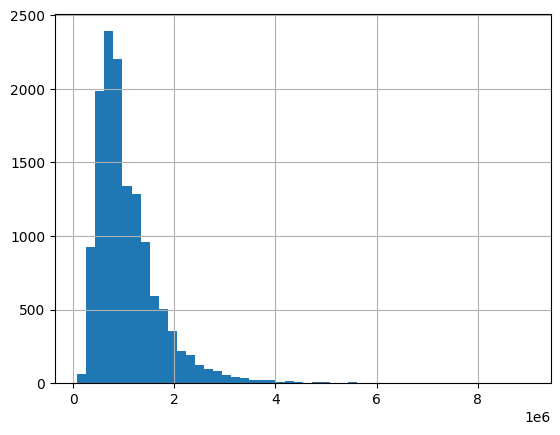

In [18]:
df['Price'].hist(bins=50)

<Axes: xlabel='Price', ylabel='Count'>

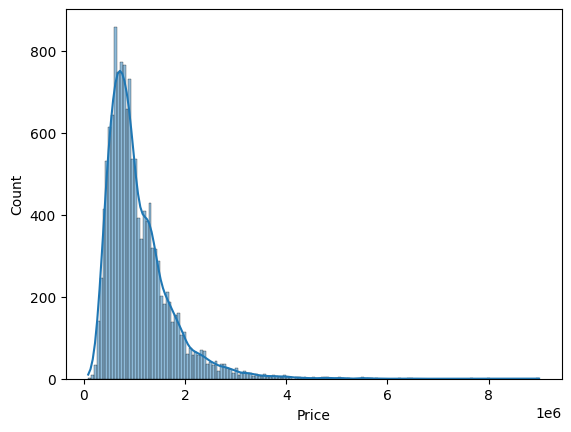

In [19]:
sns.histplot(df['Price'], kde=True)